# Importing and cleaning datasets for final visualizations

In [2]:
import pandas as pd
import re
import pycountry
import matplotlib.pyplot as plt

import pandas as pd
import json
import re
import os

## "Dwarfing" Fish Production/Landings Graph 

Data Source: FIRMS Global Tuna Atlas (https://www.fao.org/fishery/en/collection/firms-tuna-atlas)

Acronym: GTA

metadata here: https://www.fao.org/fishery/geonetwork/srv/eng/catalog.search#/metadata/global_nominal_catch_firms_level0



Catches of Bluefin species + Bigeye and Yellofin tuna up to 2025

In [2]:
#import cell is seperate so reach running of notebook starts from the same place (data un-altered)
GTA_all = pd.read_csv("../datasets/global_nominal_catch_firms_level0_harmonized.csv")
GTA_all.head()


,source_authority,fishing_fleet,time_start,time_end,geographic_identifier,gear_type,species,fishing_mode,measurement,measurement_type,measurement_unit,measurement_processing_level,measurement_value
0,CCSBT,AUS,1965-01-01,1965-12-31,IOTC,99.9,SBF,UNK,catch,NC,t,raised,4675.024565
1,CCSBT,AUS,1965-01-01,1965-12-31,WCPFC,99.9,SBF,UNK,catch,NC,t,raised,2200.975435
2,CCSBT,AUS,1966-01-01,1966-12-31,IOTC,99.9,SBF,UNK,catch,NC,t,raised,5881.819586
3,CCSBT,AUS,1966-01-01,1966-12-31,WCPFC,99.9,SBF,UNK,catch,NC,t,raised,2126.180415
4,CCSBT,AUS,1967-01-01,1967-12-31,IOTC,99.9,SBF,UNK,catch,NC,t,raised,3527.866462


In [3]:
GTA_all.dtypes
GTA_all["measurement_type"].value_counts()


measurement_type
NC    87692
NL    56408
DD     1555
DL      811
Name: count, dtype: int64

In [4]:
#first four numbers in time_start is the year -> extract and make new column
GTA_all['year'] = GTA_all['time_start'].str[:4]
#remove:
    #gear_type - cannot reasonably assume all tuna caught with certain gear type are used for the same purpose (fishing vs ranching)
    #fishing_mode
    #measurement_processing_level
    #measurement_unit - the same for all (it's tonnes)
    #source_authority
    #geographic_identifier
    #measurement
GTA_all = GTA_all.drop(columns=["measurement",'gear_type', 'fishing_mode', 'measurement_processing_level', 'measurement_unit', 'source_authority', 'geographic_identifier'])
#remove rows with measurement_type DD or DL or NL (Nominal Landings, which is a subset of NC Nominal Catch)
GTA_all = GTA_all[~GTA_all['measurement_type'].isin(['DD', 'DL', 'NL'])]
#and then drop the measurement_type column since we are only looking at one type of measurement (NC)
GTA_all = GTA_all.drop(columns=['measurement_type'])
#drop time start, time end
GTA_all = GTA_all.drop(columns=['time_start', 'time_end'])


#keep the following fish: 
    #BFT Atlantic bluefin tuna
    #BET Bigeye tuna
    #PBF Pacific bluefin tuna
    #SBF Southern bluefin tuna
    #YFT Yellowfin tuna
tuna_keep = ['BFT', 'BET', 'PBF', 'SBF', 'YFT']


GTA_tuna = GTA_all[GTA_all['species'].isin(tuna_keep)]
GTA_tuna_grouped = GTA_tuna.groupby(['species', 'year'])['measurement_value'].sum().reset_index()


In [5]:
GTA_tuna.head()

,fishing_fleet,species,measurement_value,year
0,AUS,SBF,4675.024565,1965
1,AUS,SBF,2200.975435,1965
2,AUS,SBF,5881.819586,1966
3,AUS,SBF,2126.180415,1966
4,AUS,SBF,3527.866462,1967


In [6]:
#convertor from fishing_fleet to country name 
    #each fishing fleet is a three letter abbreviation of a country name
    #these are ISO 3166 codes, more info here https://www.iso.org/iso-3166-country-codes.html
def fleet_to_country(fleet_code):
    try:
        country = pycountry.countries.get(alpha_3=fleet_code)
        return country.name
    except:
        return None
    
GTA_tuna['country'] = GTA_tuna['fishing_fleet'].apply(fleet_to_country)



/var/folders/s6/l4_0rpsd3xs3vxs6x047x7t80000gn/T/ipykernel_4366/802387118.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  GTA_tuna['country'] = GTA_tuna['fishing_fleet'].apply(fleet_to_country)


In [7]:
GTA_tuna["species"].unique()

array(['SBF', 'BET', 'PBF', 'YFT', 'BFT'], dtype=object)

### Export GTA FIRMS

In [8]:
## EXPORT
GTA_tuna.to_csv("../datasets/export/GTA_FIRMs_tuna_cleaned_countries.csv", index=False)
GTA_tuna_grouped.to_csv("../datasets/export/GTA_FIRMs_tuna_cleaned_grouped.csv", index=False)


In [13]:
GTA_tuna_grouped.head()

#total catch of SBF BFT PBF in 1965
GTA_tuna_grouped[(GTA_tuna_grouped['species'].isin(['SBF', 'BFT', 'PBF'])) & (GTA_tuna_grouped['year'] == '2007')]['measurement_value'].sum()

np.float64(90696.31779800069)

In [9]:
GTA_tuna.head(10)
#only include SBF, BFT, PBF, group by country and year, total catch in 1965
GTA_tuna[(GTA_tuna['species'].isin(['SBF', 'BFT', 'PBF'])) & (GTA_tuna['year'] == '2007')].groupby(['year'])['measurement_value'].sum()

#total catch of SBF BFT PBF summed across all years
GTA_tuna[(GTA_tuna['species'].isin(['SBF', 'BFT', 'PBF']))]['measurement_value'].sum()

np.float64(4992227.699088551)

In [ ]:
#group by species and year

GTA_tuna_grouped.head(10)


#graph only bluefins, measurement_value over time
GTA_bluefins = GTA_tuna_grouped[GTA_tuna_grouped['species'].isin(['BFT', 'PBF', 'SBF'])]
plt.figure(figsize=(10,6))
for species in ['BFT', 'PBF', 'SBF']:
    species_data = GTA_bluefins[GTA_bluefins['species'] == species]
    plt.plot(species_data['year'], species_data['measurement_value'], label=species)
plt.xlabel('Year')
plt.ylabel('Measurement Value (tonnes)')
plt.title('Global Nominal Catch of Bluefin Tuna Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#same but stacked barplot
GTA_bluefins_pivot = GTA_bluefins.pivot(index='year', columns='species', values='measurement_value').fillna(0)
GTA_bluefins_pivot.plot(kind='bar', stacked=True, figsize=(10,6))
plt.xlabel('Year')
plt.ylabel('Measurement Value (tonnes)')
plt.title('Global Nominal Catch of Bluefin Tuna Over Time (Stacked)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#stacked barplot of all tuna species
GTA_tuna_pivot = GTA_tuna_grouped.pivot(index='year', columns='species', values='measurement_value').fillna(0)
GTA_tuna_pivot.plot(kind='bar', stacked=True, figsize=(10,6))
plt.xlabel('Year')
plt.ylabel('Measurement Value (tonnes)')
plt.title('Global Nominal Catch of Tuna Species Over Time (Stacked)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Map - 5° Lat-Long of Global Tuna Catches 

Source: GTA FIRMS 


will call this object "tuna_map"

In [ ]:
tuna_map = pd.read_csv("datasets/tuna_map/global_catch_5deg_1m_firms_level0_harmonized.csv")
tuna_map.head()

In [ ]:
tuna_map["measurement_unit"].value_counts()

In [ ]:
#this is a pretty big dataset that includes all tuna and shark like species, so will treat it similarly to the previous dataset.


#create "year" column from time_start
tuna_map['year'] = tuna_map['time_start'].str[:4]

#only retain species of interest
tuna_keep = ['BFT', 'BET', 'PBF', 'SBF', 'YFT']
tuna_map_soi = tuna_map[tuna_map['species'].isin(tuna_keep)]

#remove rows with measurement_type DD or DL
tuna_map_soi = tuna_map_soi[~tuna_map_soi['measurement_type'].isin(['DD', 'DL'])]

#remove:
    #gear_type - cannot reasonably assume all tuna caught with certain gear type are used for the same purpose (fishing vs ranching)
    #fishing_mode
    #measurement_processing_level
    #source_authority
    #measurement
    #time_start
    #time_end
tuna_map_soi = tuna_map_soi.drop(columns=['gear_type', 'fishing_mode', 'measurement_processing_level', 'source_authority', 'measurement', 'measurement_type', 'time_start', 'time_end'])



In [ ]:
tuna_map_soi.head()

In [ ]:
tuna_map_soi["measurement_unit"].value_counts()

In [ ]:
#map with only tuna of interst, only neccesary columns
tuna_map_soi.head()

#need to figure out what to do with count vs tonne data
tuna_map_soi_tonne = tuna_map_soi[tuna_map_soi['measurement_unit'] == 't']
tuna_map_soi_count = tuna_map_soi[tuna_map_soi['measurement_unit'] == 'no']


In [ ]:
#group by geographic identifier, year, and species, sum measurement value
tuna_map_soi_count_grouped = tuna_map_soi_count.groupby(['geographic_identifier', 'year', 'species'])['measurement_value'].sum().reset_index()
tuna_map_soi_tonne_grouped = tuna_map_soi_tonne.groupby(['geographic_identifier', 'year', 'species'])['measurement_value'].sum().reset_index()
tuna_map_soi_count_grouped.head()

In [ ]:
#what is the first year of data for each species?
tuna_map_soi_count_grouped.groupby('species')['year'].min()

#remove years before 1965 for even coverage across species
tuna_map_soi_count_grouped = tuna_map_soi_count_grouped[tuna_map_soi_count_grouped['year'] >= '1965']
tuna_map_soi_tonne_grouped = tuna_map_soi_tonne_grouped[tuna_map_soi_tonne_grouped['year'] >= '1965']
tuna_map_soi_tonne_grouped.head()

In [ ]:
#bluefin (BFT, PBF, SBF) only subset
tuna_map_soi_tonne_bluefin = tuna_map_soi_tonne_grouped[tuna_map_soi_tonne_grouped['species'].isin(['BFT', 'PBF', 'SBF'])]
tuna_map_soi_count_bluefin = tuna_map_soi_count_grouped[tuna_map_soi_count_grouped['species'].isin(['BFT', 'PBF', 'SBF'])]

#### EXPORT tuna dataset for map

In [ ]:
#export tonne and count
tuna_map_soi_count_grouped.to_csv("datasets/export/tuna_map_count.csv")
tuna_map_soi_tonne_grouped.to_csv("datasets/export/tuna_map_tonne.csv")

#export bluefin subsets
tuna_map_soi_count_bluefin.to_csv("datasets/export/tuna_map_count_bluefin.csv")
tuna_map_soi_tonne_bluefin.to_csv("datasets/export/tuna_map_tonne_bluefin.csv")

### Geographic Key for tuna map

Source: https://www.fao.org/fishery/geonetwork/srv/eng/catalog.search#/metadata/cwp-grid-map-5deg_x_5deg

Key for 5° by 5° grid overlaid on earth

In [ ]:
map_geographic_key = pd.read_csv("datasets/tuna_map/cwp-grid-map-5deg_x_5deg.csv")
map_geographic_key.head()

transforming this into mapbox-readable geojson

In [ ]:
"""
build_catch_geojson.py
----------------------
Merges tuna catch CSVs (count + tonne) into the CWP 5° grid GeoJSON
using wide format (one column per year).

Inputs:
  - cwp-grid-5deg.geojson       (corrected grid from previous step)
  - tuna_map_count.csv
  - tuna_map_tonne.csv

Output:
  - cwp-grid-5deg-catch.geojson

Usage:
  python build_catch_geojson.py
"""

import pandas as pd
import json
import os

# ── Paths (edit these if needed) ─────────────────────────────────────────────
GRID_GEOJSON  = 'datasets/tuna_map/cwp-grid-5deg-var3.geojson'
COUNT_CSV     = 'datasets/export/tuna_map_count_bluefin.csv'
TONNE_CSV     = 'datasets/export/tuna_map_tonne_bluefin.csv'
OUTPUT_GEOJSON = 'datasets/export/cwp-grid-5deg-catch-bluefin.geojson'

# ── 1. Load and pivot catch data to wide format ───────────────────────────────
print("Loading catch data...")
count_df = pd.read_csv(COUNT_CSV)
tonne_df = pd.read_csv(TONNE_CSV)

def to_wide(df, prefix):
    """Aggregate all species per square per year, then pivot to wide."""
    return (df
        .groupby(['geographic_identifier', 'year'])['measurement_value']
        .sum()
        .reset_index()
        .pivot(index='geographic_identifier', columns='year', values='measurement_value')
        .rename(columns=lambda y: f'{prefix}_{y}'))

count_wide = to_wide(count_df, 'count')
tonne_wide = to_wide(tonne_df, 'tonne')

catch_wide = count_wide.join(tonne_wide, how='outer')
catch_wide.index.name = 'CWP_CODE'
catch_wide = catch_wide.reset_index()

print(f"  Wide table: {catch_wide.shape[0]} squares × {catch_wide.shape[1]} columns")

# ── 2. Load GeoJSON ───────────────────────────────────────────────────────────
print(f"Loading {GRID_GEOJSON}...")
with open(GRID_GEOJSON) as f:
    geojson = json.load(f)

# ── 3. Merge catch data into GeoJSON properties ───────────────────────────────
print("Merging...")
catch_lookup = catch_wide.set_index('CWP_CODE').to_dict(orient='index')

matched, unmatched = 0, 0
for feature in geojson['features']:
    code = feature['properties']['CWP_CODE']
    if code in catch_lookup:
        for k, v in catch_lookup[code].items():
            feature['properties'][k] = (
                None if (isinstance(v, float) and pd.isna(v))
                else round(float(v), 3)
            )
        matched += 1
    else:
        unmatched += 1

print(f"  Matched: {matched} | No catch data: {unmatched}")

# ── 4. Write output ───────────────────────────────────────────────────────────
print(f"Writing {OUTPUT_GEOJSON}...")
with open(OUTPUT_GEOJSON, 'w') as f:
    json.dump(geojson, f)

size_mb = os.path.getsize(OUTPUT_GEOJSON) / 1e6
print(f"Done. Output: {OUTPUT_GEOJSON} ({size_mb:.1f} MB)")

### FIRMS Global Tuna Atlas 1° lat-long
https://zenodo.org/records/17707421

In [3]:
tuna_1deg = pd.read_csv("../datasets/tuna_map/global_catch_1deg_1m_surface_firms_level0_harmonized.csv")
tuna_1deg.head()


,source_authority,fishing_fleet,time_start,time_end,geographic_identifier,gear_type,species,fishing_mode,measurement,measurement_type,measurement_unit,measurement_processing_level,measurement_value
0,CCSBT,AUS,1975-12-01,1975-12-31,5237150,1.1,SBF,UNK,catch,RC,t,unknown,59.8
1,CCSBT,AUS,1976-09-01,1976-09-30,5237150,9.1,SBF,UNK,catch,RC,t,unknown,36.2
2,CCSBT,AUS,1976-10-01,1976-10-31,5237150,9.1,SBF,UNK,catch,RC,t,unknown,41.0
3,CCSBT,AUS,1976-12-01,1976-12-31,5232132,9.1,SBF,UNK,catch,RC,t,unknown,167.5
4,CCSBT,AUS,1976-12-01,1976-12-31,5233134,9.1,SBF,UNK,catch,RC,t,unknown,35.6


In [4]:
#same processing as 5deg

#create "year" column from time_start
tuna_1deg['year'] = tuna_1deg['time_start'].str[:4]

#only retain species of interest
tuna_keep = ['BFT', 'PBF', 'SBF',]
tuna_1deg_soi = tuna_1deg[tuna_1deg['species'].isin(tuna_keep)]

#remove rows with measurement_type DD or DL
tuna_1deg_soi = tuna_1deg_soi[~tuna_1deg_soi['measurement_type'].isin(['DD', 'DL'])]


#remove:
    #gear_type - cannot reasonably assume all tuna caught with certain gear type are used for the same purpose (fishing vs ranching)
    #fishing_mode
    #measurement_processing_level
    #source_authority
    #measurement
    #time_start
    #time_end
tuna_1deg_soi = tuna_1deg_soi.drop(columns=['gear_type', 'fishing_mode', 'measurement_processing_level', 'source_authority', 'measurement', 'measurement_type', 'time_start', 'time_end'])

#filter out number (no) - onlly 487 rows compared to 1100822 tonne rows
tuna_1deg_soi = tuna_1deg_soi[tuna_1deg_soi['measurement_unit'] == 't']

tuna_1deg_soi.head()

,fishing_fleet,geographic_identifier,species,measurement_unit,measurement_value,year
0,AUS,5237150,SBF,t,59.8,1975
1,AUS,5237150,SBF,t,36.2,1976
2,AUS,5237150,SBF,t,41.0,1976
3,AUS,5232132,SBF,t,167.5,1976
4,AUS,5233134,SBF,t,35.6,1976


In [5]:
#group by geographic identifier, year, and species, sum measurement value
tuna_1deg_soi_grouped = tuna_1deg_soi.groupby(['geographic_identifier', 'year', 'species'])['measurement_value'].sum().reset_index()


#check earliest years and filter to same baseline
tuna_1deg_soi_grouped.groupby('species')['year'].min()

#separate 1975-present baseline dataset
tuna_1deg_1975 = tuna_1deg_soi_grouped[tuna_1deg_soi_grouped['year'] >= '1975']



In [6]:
tuna_1deg_soi["measurement_unit"].value_counts()

measurement_unit
t    6227
Name: count, dtype: int64

geojson script below:

In [9]:
"""
build_catch_geojson_1deg.py
---------------------------
Converts the CWP 1°x1° grid CSV + tuna catch CSV into a merged GeoJSON
for use in Mapbox, using wide format (one column per year).

Inputs:
  - cwp-grid-map-1deg_x_1deg.csv   (CWP grid with WKT geometry)
  - tuna_1deg_soi_grouped.csv      (catch data: geographic_identifier, year, species, measurement_value)

Outputs:
  - cwp-grid-1deg.geojson          (full grid, all squares)
  - cwp-grid-1deg-sea.geojson      (sea-only squares, smaller file)
  - cwp-grid-1deg-catch.geojson    (sea-only squares + catch data merged in)

Usage:
  python build_catch_geojson_1deg.py

Note on file size:
  At 1°x1° resolution (64,800 squares) the full GeoJSON is ~26 MB.
  The sea-only + catch merged output is ~28 MB. For Mapbox GL JS,
  consider hosting via Mapbox Tileset API (converts to vector tiles)
  rather than loading as a raw GeoJSON source, which will be slow.
"""



# ── Paths (edit these if needed) ─────────────────────────────────────────────
GRID_CSV        = '../datasets/tuna_map/cwp-grid-map-1deg_x_1deg.csv'
CATCH_CSV       = '../datasets/export/bluefin-tuna_1deg_soi_grouped.csv'
OUTPUT_GRID     = '../datasets/export/geojson_export/bluefin-cwp-grid-1deg.geojson'
OUTPUT_SEA      = '../datasets/export/geojson_export/bluefin-cwp-grid-1deg-sea.geojson'
OUTPUT_CATCH    = '../datasets/export/geojson_export/bluefin-cwp-grid-1deg-catch.geojson'

# ── Step 1: Convert grid CSV → GeoJSON (fix WKT axis swap) ───────────────────
print("Building grid GeoJSON...")

def parse_wkt_multipolygon(wkt_str):
    """
    Parse WKT MULTIPOLYGON to GeoJSON coordinates.
    The source WKT uses (lat, lon) order — this swaps all pairs to (lon, lat)
    as required by GeoJSON / Mapbox.
    """
    s = wkt_str.strip()[len('MULTIPOLYGON '):].strip()[1:-1]
    polygons = []
    for match in re.finditer(r'\(\((.*?)\)\)', s, re.DOTALL):
        rings = []
        for ring in re.split(r'\)\s*,\s*\(', match.group(1)):
            coords = []
            for pair in ring.strip().split(','):
                parts = pair.strip().split()
                if len(parts) >= 2:
                    lat, lon = float(parts[0]), float(parts[1])
                    coords.append([lon, lat])  # swap to GeoJSON (lon, lat)
            rings.append(coords)
        polygons.append(rings)
    return polygons

df = pd.read_csv(GRID_CSV)
features = []
for _, row in df.iterrows():
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "MultiPolygon",
            "coordinates": parse_wkt_multipolygon(row['the_geom'])
        },
        "properties": {
            "FID":       row['FID'],
            "CWP_CODE":  int(row['CWP_CODE']),
            "GRIDTYPE":  row['GRIDTYPE'],
            "QUADRANT":  row['QUADRANT'],
            "X_COORD":   row['X_COORD'],
            "Y_COORD":   row['Y_COORD'],
            "CWP_A":     row['CWP_A'],
            "CWP_B":     row['CWP_B'],
            "CWP_C":     row['CWP_C'],
            "CWP_D":     row['CWP_D'],
            "ON_SEA_P":  row['ON_SEA_P'],
            "ON_LAND_P": row['ON_LAND_P'],
        }
    })

geojson = {"type": "FeatureCollection", "features": features}
with open(OUTPUT_GRID, 'w') as f:
    json.dump(geojson, f)
print(f"  {len(features)} features → {os.path.getsize(OUTPUT_GRID)/1e6:.1f} MB  ({OUTPUT_GRID})")

# ── Step 2: Filter to sea-only squares ───────────────────────────────────────
print("Filtering to sea-only squares...")
sea_features = [f for f in features if (f['properties']['ON_SEA_P'] or 0) > 0]
sea_geojson = {"type": "FeatureCollection", "features": sea_features}
with open(OUTPUT_SEA, 'w') as f:
    json.dump(sea_geojson, f)
print(f"  {len(sea_features)} features → {os.path.getsize(OUTPUT_SEA)/1e6:.1f} MB  ({OUTPUT_SEA})")

# ── Step 3: Pivot catch data to wide format ───────────────────────────────────
print("Loading and pivoting catch data...")
catch_df = pd.read_csv(CATCH_CSV)

tonne_wide = (catch_df
    .groupby(['geographic_identifier', 'year'])['measurement_value']
    .sum()
    .reset_index()
    .pivot(index='geographic_identifier', columns='year', values='measurement_value')
    .rename(columns=lambda y: f'tonne_{y}'))
tonne_wide.index.name = 'CWP_CODE'
tonne_wide = tonne_wide.reset_index()

print(f"  {tonne_wide.shape[0]} squares × {tonne_wide.shape[1]} columns "
      f"(tonne_{catch_df['year'].min()} … tonne_{catch_df['year'].max()})")

# ── Step 4: Merge catch into sea GeoJSON ─────────────────────────────────────
print("Merging catch data into GeoJSON...")
catch_lookup = tonne_wide.set_index('CWP_CODE').to_dict(orient='index')

matched, unmatched = 0, 0
for feature in sea_geojson['features']:
    code = feature['properties']['CWP_CODE']
    if code in catch_lookup:
        for k, v in catch_lookup[code].items():
            feature['properties'][k] = (
                None if (isinstance(v, float) and pd.isna(v))
                else round(float(v), 3)
            )
        matched += 1
    else:
        unmatched += 1

print(f"  Matched: {matched} | No catch data: {unmatched}")

with open(OUTPUT_CATCH, 'w') as f:
    json.dump(sea_geojson, f)
print(f"  → {os.path.getsize(OUTPUT_CATCH)/1e6:.1f} MB  ({OUTPUT_CATCH})")
print("Done.")

Building grid GeoJSON...
  64800 features → 26.0 MB  (../datasets/export/geojson_export/bluefin-cwp-grid-1deg.geojson)
Filtering to sea-only squares...
  46513 features → 18.7 MB  (../datasets/export/geojson_export/bluefin-cwp-grid-1deg-sea.geojson)
Loading and pivoting catch data...
  451 squares × 67 columns (tonne_1959 … tonne_2024)
Merging catch data into GeoJSON...
  Matched: 445 | No catch data: 46068
  → 19.3 MB  (../datasets/export/geojson_export/bluefin-cwp-grid-1deg-catch.geojson)
Done.


## Export tuna_1deg and tuna_1deg 1975

In [8]:
tuna_1deg_soi_grouped.to_csv("../datasets/export/bluefin-tuna_1deg_soi_grouped.csv", index=False)
tuna_1deg_1975.to_csv("../datasets/export/bluefin-tuna_1deg_soi_grouped_1975.csv", index=False)

## NOAA Import/Export

https://www.fisheries.noaa.gov/foss/f?p=215:2:14285563639484:::::

In [ ]:
fish_import_export = pd.read_csv("datasets/noaa_import_export_tunas.csv")
#column names are in first row, so set header to 0 and skip the first row
fish_import_export.columns = fish_import_export.iloc[0]
fish_import_export = fish_import_export[1:]
fish_import_export.head()


In [ ]:
#year to int
fish_import_export['Year'] = fish_import_export['Year'].astype(int)
# value and volume have commas, so remove commas and convert to int
fish_import_export['Value (USD)'] = fish_import_export['Value (USD)'].str.replace(',', '').astype(int)
fish_import_export['Volume (kg)'] = fish_import_export['Volume (kg)'].str.replace(',', '').astype(int)
#drop calculated duty and edible code
fish_import_export = fish_import_export.drop(columns=['Calculated Duty (USD)', 'Edible code'])




In [ ]:
fish_import_export.dtypes
fish_import_export.head()


In [ ]:
#get rid of:
    #anything that includes the word EVISCERATED
    #OTHER PREPARATIONS
keywords_to_remove = ['EVISCERATED', 'OTHER PREPARATIONS'] #use these keywords to filter
fish_import_export = fish_import_export[~fish_import_export["Product Name"].str.contains('|'.join(keywords_to_remove))]

#All Product Name containing TUNA BLUEFIN become TUNA BLUEFIN 
fish_import_export["Product Name"] = fish_import_export["Product Name"].str.replace(r'TUNA BLUEFIN.*', 'TUNA BLUEFIN', regex=True)
#same for YELLOWFIN and BIGEYE
fish_import_export["Product Name"] = fish_import_export["Product Name"].str.replace(r'TUNA YELLOWFIN.*', 'TUNA YELLOWFIN', regex=True)
fish_import_export["Product Name"] = fish_import_export["Product Name"].str.replace(r'TUNA BIGEYE.*', 'TUNA BIGEYE', regex=True)


fish_import_export["Product Name"].value_counts()


In [ ]:
#also prepare bluefin import only subsection
fish_import_bluefin = fish_import_export[fish_import_export["Product Name"].str.contains("TUNA BLUEFIN")]
fish_import_bluefin = fish_import_bluefin[fish_import_bluefin["Source"] == "IMP"]
fish_import_bluefin.head()

### Export NOAA imp/exp

In [ ]:
fish_import_export.to_csv("datasets/export/noaa_import_export_tunas_combined_cleaned.csv", index=False)
fish_import_bluefin.to_csv("datasets/export/noaa_import_tunas_bluefin.csv", index=False)

# Global Tuna Aquaculture
From UN FAO 

link: https://www.fao.org/fishery/en/collection/global_production?lang=en

big dataset, filtering down for only bluefin tuna

Columns needed:

- PRODUCTION_SOURCE_DET.CODE
    - CAPTURE is wild caught
    - MARINE is marine aquaculture
- PERIOD (year)
- MEASURE
    - Q_tlw is tonnes - live weight
- AREA.CODE
    - gives production area. could be useful?


In [ ]:
#import helper datasets 
country_codes = pd.read_csv("../datasets/GlobalProduction/CL_FI_COUNTRY_GROUPS.csv")
area_codes = pd.read_csv("../datasets/GlobalProduction/CL_FI_WATERAREA_GROUPS.csv")
country_codes.head() #take UN_Code, ISO3_Code, and Name_En columns for assinging country names
area_codes.head() #take Code and Name_En cols


#import dataset
global_production = pd.read_csv("../datasets/GlobalProduction/Global_production_quantity.csv")
global_production.head()

,COUNTRY.UN_CODE,SPECIES.ALPHA_3_CODE,AREA.CODE,PRODUCTION_SOURCE_DET.CODE,MEASURE,PERIOD,VALUE,STATUS
0,4,FRF,4,CAPTURE,Q_tlw,2022,2000.0,I
1,4,FRF,4,CAPTURE,Q_tlw,2021,1800.0,I
2,4,FRF,4,CAPTURE,Q_tlw,2020,2000.0,I
3,4,FRF,4,CAPTURE,Q_tlw,2019,2100.0,I
4,4,FRF,4,CAPTURE,Q_tlw,2018,2050.0,I


In [22]:
#bluefin tuna specific dataset:
gp_bluefin = global_production[global_production['SPECIES.ALPHA_3_CODE'].isin(['SBF', 'BFT', 'PBF'])]
gp_bluefin.head()


,COUNTRY.UN_CODE,SPECIES.ALPHA_3_CODE,AREA.CODE,PRODUCTION_SOURCE_DET.CODE,MEASURE,PERIOD,VALUE,STATUS
2021,8,BFT,37,CAPTURE,Q_tlw,2022,169.000,A
2022,8,BFT,37,CAPTURE,Q_tlw,2021,163.000,A
2023,8,BFT,37,CAPTURE,Q_tlw,2020,167.665,A
2024,8,BFT,37,CAPTURE,Q_tlw,2019,156.000,A
2025,8,BFT,37,CAPTURE,Q_tlw,2018,100.000,A


In [23]:
def assign_names(df, country_codes, area_codes):
    """
    Assigns country and area names to gp_bluefin dataset.
    
    Parameters:
    - df: gp_bluefin dataframe
    - country_codes: dataframe with UN_Code and Name_En columns
    - area_codes: dataframe with Code and Name_En columns
    
    Returns:
    - df with added 'country_name' and 'area_name' columns
    """
    # Create lookup dictionaries
    country_lookup = dict(zip(country_codes['UN_Code'], country_codes['Name_En']))
    area_lookup = dict(zip(area_codes['Code'], area_codes['Name_En']))
    
    # Map names using the lookups
    df['country_name'] = df['COUNTRY.UN_CODE'].map(country_lookup)
    df['area_name'] = df['AREA.CODE'].map(area_lookup)
    
    return df

# Apply the function
gp_bluefin = assign_names(gp_bluefin, country_codes, area_codes)

/var/folders/s6/l4_0rpsd3xs3vxs6x047x7t80000gn/T/ipykernel_55936/1179350969.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['country_name'] = df['COUNTRY.UN_CODE'].map(country_lookup)
/var/folders/s6/l4_0rpsd3xs3vxs6x047x7t80000gn/T/ipykernel_55936/1179350969.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['area_name'] = df['AREA.CODE'].map(area_lookup)


In [24]:
#drop cols: COUNTRY.UN_CODE, AREA.CODE, MEASURE, STATUS
gp_bluefin = gp_bluefin.drop(columns=['COUNTRY.UN_CODE', 'AREA.CODE', 'MEASURE', 'STATUS'])
#rename SPECIES.ALPHA_3_CODE to species, PRODUCTION_SOURCE_DET.CODE to production_type, PERIOD to year, VALUE to measurement_value
gp_bluefin = gp_bluefin.rename(columns={
    'SPECIES.ALPHA_3_CODE': 'species',
    'PRODUCTION_SOURCE_DET.CODE': 'production_type',
    'PERIOD': 'year',
    'VALUE': 'measurement_value'
})


In [25]:
gp_bluefin.head()

,species,production_type,year,measurement_value,country_name,area_name
2021,BFT,CAPTURE,2022,169.000,Albania,Mediterranean and Black Sea
2022,BFT,CAPTURE,2021,163.000,Albania,Mediterranean and Black Sea
2023,BFT,CAPTURE,2020,167.665,Albania,Mediterranean and Black Sea
2024,BFT,CAPTURE,2019,156.000,Albania,Mediterranean and Black Sea
2025,BFT,CAPTURE,2018,100.000,Albania,Mediterranean and Black Sea


In [28]:
#groupy by species, and then year, and then production type
gp_bluefin_grouped = gp_bluefin.groupby(['year', 'production_type'])['measurement_value'].sum().reset_index()
gp_bluefin_grouped.head()

,year,production_type,measurement_value
0,1950,CAPTURE,27540.0
1,1950,MARINE,0.0
2,1951,CAPTURE,31176.0
3,1951,MARINE,0.0
4,1952,CAPTURE,69670.0


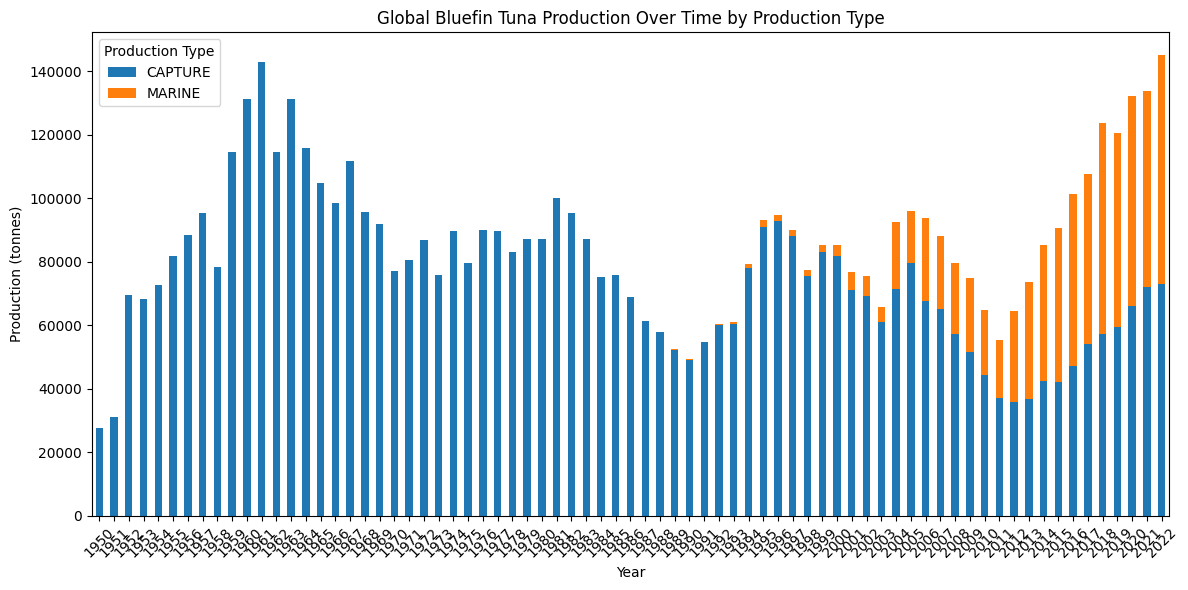

In [33]:
#graph bluefin tuna production over time by production type using gp_bluefin_grouped stacked barplot with year on x measurement on y


# Create pivot table for stacked barplot
gp_bluefin_pivot = gp_bluefin_grouped.pivot(index='year', columns='production_type', values='measurement_value').fillna(0)

# Create stacked barplot
gp_bluefin_pivot.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel('Year')
plt.ylabel('Production (tonnes)')
plt.title('Global Bluefin Tuna Production Over Time by Production Type')
plt.legend(title='Production Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### export grouped data - only aquaculture/wild capture by year

In [34]:
#export cleaned and grouped bluefin
gp_bluefin_grouped.to_csv("../datasets/export/bluefin_aquaculture.csv", index=False)